<a href="https://colab.research.google.com/github/Gus-oss/COVID-19/blob/main/Covid_19V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
#Importamos las librerias que utilizaremos a lo largo del documento
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm

In [106]:
import requests
from bs4 import BeautifulSoup

# URL de la página de datos abiertos
url = 'https://www.gob.mx/salud/documentos/datos-abiertos-152127'

# Obtener el HTML de la página
response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.content, 'html.parser')

# Imprimir todos los enlaces en la página para ver su estructura
print("Enlaces encontrados en la página:")
for a in soup.find_all('a', href=True):
    print(a['href'])


Enlaces encontrados en la página:
/
/tramites
/gobierno
/salud/en
https://www.gob.mx/busqueda?utf8=✓
?tab=
/salud/es/archivo/prensa
/salud/es/archivo/acciones_y_programas
http://portal.salud.gob.mx/sites/transparencia/transparencia/proteccion_datos/proteccion_1_1.html
http://portal.salud.gob.mx/sites/transparencia/transparencia/transparencia/transparencia_1.html
http://www.gob.mx
/salud
/salud/articulos/estres-ansiedad-y-depresion-favorecen-desarrollo-de-sindrome-de-intestino-irritable
/salud/articulos/contra-el-cancer-yo-actuo
/salud/articulos/jornada-nacional-de-salud-publica-2024-373549
/salud/articulos/sitios-de-interes-370269
/salud/articulos/capsulas-de-cancer
https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/datos_abiertos_influenza_covid19.zip
https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/diccionario_datos_abiertos.zip
https://www.gob.mx/salud/documentos/datos-abiertos-bases-historicas-direccion-general-de-epidemiologia
https://datosabiertos.salud.go

In [107]:
import requests
import zipfile
import io

# URL del Diccionario de datos
diccionario_url = 'https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/diccionario_datos_abiertos.zip'

# Descargar y abrir el archivo ZIP del Diccionario de datos
diccionario_zip_response = requests.get(diccionario_url)
diccionario_zip_response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(diccionario_zip_response.content)) as diccionario_zip:
    # Listar los nombres de los archivos en el ZIP
    print("Archivos contenidos en el ZIP del Diccionario de datos:")
    for file_name in diccionario_zip.namelist():
        print(file_name)


Archivos contenidos en el ZIP del Diccionario de datos:
240708 Catalogos.xlsx
240708 Descriptores_.xlsx
Actualizaciones en la presentación de información referente a casos de COVID.pdf


In [108]:
import requests
import zipfile
import io
import pandas as pd

# URLs directas para los archivos ZIP
covid_data_url = 'https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/datos_abiertos_influenza_covid19.zip'
diccionario_url = 'https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/diccionario_datos_abiertos.zip'

def descargar_datos_covid():
    # Descargar y procesar el archivo ZIP de datos COVID-19
    print("Descargando archivo ZIP de datos COVID-19 desde:", covid_data_url)
    covid_zip_response = requests.get(covid_data_url)
    covid_zip_response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(covid_zip_response.content)) as covid_zip:
        for file_name in covid_zip.namelist():
            if file_name.endswith('.csv'):
                print(f"Extrayendo {file_name}...")
                with covid_zip.open(file_name) as csv_file:
                    df_covid = pd.read_csv(csv_file)
                    print("Datos COVID-19 cargados correctamente en el DataFrame.")
                    break  # Salir después de encontrar el archivo CSV

    # Descargar y procesar el archivo ZIP del Diccionario de datos
    print("Descargando archivo ZIP del Diccionario de datos desde:", diccionario_url)
    diccionario_zip_response = requests.get(diccionario_url)
    diccionario_zip_response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(diccionario_zip_response.content)) as diccionario_zip:
        # Cargar los archivos Excel
        excel_file_catalogos = pd.read_excel(diccionario_zip.open('240708 Catalogos.xlsx'))
        df_descriptores = pd.read_excel(diccionario_zip.open('240708 Descriptores_.xlsx'))
        print("Archivos del Diccionario de datos cargados correctamente en DataFrames.")

        # Cargar hojas específicas en DataFrames separados
        df_enti = pd.read_excel(diccionario_zip.open('240708 Catalogos.xlsx'), sheet_name='Catálogo de ENTIDADES')
        df_muni = pd.read_excel(diccionario_zip.open('240708 Catalogos.xlsx'), sheet_name='Catálogo MUNICIPIOS')
        df_sector = pd.read_excel(diccionario_zip.open('240708 Catalogos.xlsx'), sheet_name='Catálogo SECTOR')
        df_pcr = pd.read_excel(diccionario_zip.open('240708 Catalogos.xlsx'), sheet_name='Catálogo RESULTADO_PCR')

    return df_covid, excel_file_catalogos, df_descriptores, df_enti, df_muni, df_sector, df_pcr

# Ejecutar la función y cargar los datos en los DataFrames
df_covid, excel_file_catalogos, df_descriptores, df_enti, df_muni, df_sector, df_pcr = descargar_datos_covid()

Descargando archivo ZIP de datos COVID-19 desde: https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/datos_abiertos_influenza_covid19.zip
Extrayendo COVID19MEXICO.csv...
Datos COVID-19 cargados correctamente en el DataFrame.
Descargando archivo ZIP del Diccionario de datos desde: https://datosabiertos.salud.gob.mx/gobmx/salud/datos_abiertos/diccionario_datos_abiertos.zip
Archivos del Diccionario de datos cargados correctamente en DataFrames.


In [109]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-11-12,0aa89f,1,10,9,2,15,9,3,1,...,5,5,2,97,7,7,99,México,97,97
1,2024-11-12,gaa8ce3,1,12,9,1,9,15,13,1,...,1,998,2,97,7,3,99,México,97,97
2,2024-11-12,g824984,1,4,32,2,32,32,17,2,...,34,29,2,97,3,7,99,México,97,2
3,2024-11-12,gdb0743,1,3,19,2,19,19,39,1,...,5,5,2,97,7,7,99,México,97,97
4,2024-11-12,gd16cbd,1,15,32,1,32,32,17,1,...,34,998,2,97,3,7,99,México,97,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153168,2024-11-12,ga923f7,1,3,15,2,15,15,104,1,...,997,997,2,97,6,6,99,México,97,97
153169,2024-11-12,ge76abb,1,4,2,2,2,2,2,2,...,999,999,2,97,6,6,99,México,97,2
153170,2024-11-12,g60370b,1,2,13,1,13,13,37,2,...,999,999,2,97,6,6,99,México,97,2
153171,2024-11-12,gee1529,1,15,26,2,26,26,30,2,...,999,999,2,97,6,6,99,México,97,2


# Limpieza de datos
 La limpieza de datos es un paso crucial para asegurar que el analisis sea presiso y confiable . Aqui manejamos valores nulos y eliminaremos duplicados.

 En esta limpieza vamos a remplasar todos los valores numericos como "Sexo" que tienen 1 para hombre y 2 para mujer para tener toda la informacion en el df_covid principal sin necesidad de utilizar los otros documentos

In [110]:
# 1. Revisión de valores faltantes (NaN)
# Verificamos cuántos valores faltantes hay por columna
valores_nulos = df_covid.isnull().sum()
print("Valores faltantes por columna:\n", valores_nulos)

Valores faltantes por columna:
 FECHA_ACTUALIZACION          0
ID_REGISTRO                  0
ORIGEN                       0
SECTOR                       0
ENTIDAD_UM                   0
SEXO                         0
ENTIDAD_NAC                  0
ENTIDAD_RES                  0
MUNICIPIO_RES                0
TIPO_PACIENTE                0
FECHA_INGRESO                0
FECHA_SINTOMAS               0
FECHA_DEF                    0
INTUBADO                     0
NEUMONIA                     0
EDAD                         0
NACIONALIDAD                 0
EMBARAZO                     0
HABLA_LENGUA_INDIG           0
INDIGENA                     0
DIABETES                     0
EPOC                         0
ASMA                         0
INMUSUPR                     0
HIPERTENSION                 0
OTRA_COM                     0
CARDIOVASCULAR               0
OBESIDAD                     0
RENAL_CRONICA                0
TABAQUISMO                   0
OTRO_CASO                    0
TOMA_MU

No hay valores nulos en las columnas del dataset

In [111]:
# 2. Revisión de datos inconsistentes o erróneos
# Por ejemplo, asegurémonos de que las edades estén en un rango lógico (0-120)
df_covid = df_covid[(df_covid['EDAD'] >= 0) & (df_covid['EDAD'] <= 120)]

# 3. Eliminar duplicados
# Revisamos si hay filas duplicadas y las eliminamos si las encontramos
df_covid = df_covid.drop_duplicates()

In [112]:
# 4. Revisión de tipos de datos
# Convertimos las columnas de fecha a formato datetime para análisis temporal
df_covid['FECHA_INGRESO'] = pd.to_datetime(df_covid['FECHA_INGRESO'], errors='coerce')
df_covid['FECHA_SINTOMAS'] = pd.to_datetime(df_covid['FECHA_SINTOMAS'], errors='coerce')
df_covid['FECHA_DEF'] = pd.to_datetime(df_covid['FECHA_DEF'], errors='coerce')

<ipython-input-112-7c63ea935cb2>:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_covid['FECHA_DEF'] = pd.to_datetime(df_covid['FECHA_DEF'], errors='coerce')


In [113]:
#Esto es lo que hay que cambiar para que en lugar de sea manual tenga que ser
# automatico, es decir que agarre los datos del catalogo y que los intercambier
# por los datos que se encuentran en el dataframe del covid

# 5. Codificación de valores categóricos
# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna SEXO
df_covid['SEXO'] = df_covid['SEXO'].replace({1: 'Hombre', 2: 'Mujer', 99: 'No Especificado'})

#Remplazamos valores numericos por etiquetas en la columna Origen
df_covid['ORIGEN'] = df_covid['ORIGEN'].replace({1: 'usmer', 2: 'Fuera de usmer', 99: 'No Especificado'})

# Las USMERs son centros de salud y hospitales ubicados en puntos estratégicos con la capacidad de realizar
# vigilancia de enfermedades respiratorias

#Remplazamos valores numericos por etiquetas en la comuna de Tipo_Paciente
df_covid['TIPO_PACIENTE'] = df_covid['TIPO_PACIENTE'].replace({1: 'Ambulatorio', 2: 'Hospitalizado', 99: 'No Especificado'})


#Remplazamos valores numericos por etiquetas en la comuna TOMA_MUESTRA_ANTIGENO
df_covid['TOMA_MUESTRA_ANTIGENO'] = df_covid['TOMA_MUESTRA_ANTIGENO'].replace({
    1: 'Si',
    2: 'No',
    97: 'No Aplica',
    98: 'Se ignora',
    99: 'No especificado'})


#Remplazamos valores numericos por etiquetas en la comuna RESULTADO_ANTIGENO
df_covid['RESULTADO_ANTIGENO'] = df_covid['RESULTADO_ANTIGENO'].replace({
    1: 'Positivo a Sars-cov-2',
    2: 'Negativo a Sars-cov-2',
    97:'No Aplica (caso sin muestra)'})


# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna CLASIFICACION_FINAL_COVID
df_covid['CLASIFICACION_FINAL_COVID'] = df_covid['CLASIFICACION_FINAL_COVID'].replace({
    1: 'Caso de Covid-19 confirmado por asociación clínica epidemica',
    2: 'Caso de Covid_19 confirmado por comité de dictamen ',
    3: 'Caso de Sars-COV-2 confirmado',
    4: 'Invalido por laboratorio',
    5: 'No realizado por laboratorio',
    6: 'Caso sospechoso',
    7: 'Negativo a Sars-cov-2'})


# Reemplazamos valores numéricos por etiquetas, por ejemplo, en la columna MIGRANTE
df_covid['MIGRANTE'] = df_covid['MIGRANTE'].replace({
    1: 'Si', 2: 'No', 97: 'No Aplica', 98: 'Se ignora', 99: 'No especificado'})

#Remplazamos valores numericos por etiquetas en la columna de UCI
df_covid['UCI'] = df_covid['UCI'].replace({
    1: 'Si', 2: 'No', 97: 'No Aplica', 98: 'Se ignora', 99: 'No especificado'})

In [114]:
#  Ahora realizaremos lo mismo pero para las entidades
#  pero de forma automatizada
# Extraemos el catálogo de entidades
df_enti

,CLAVE_ENTIDAD,ENTIDAD_FEDERATIVA,ABREVIATURA
0,1,AGUASCALIENTES,AS
1,2,BAJA CALIFORNIA,BC
2,3,BAJA CALIFORNIA SUR,BS
3,4,CAMPECHE,CC
4,5,COAHUILA DE ZARAGOZA,CL
5,6,COLIMA,CM
6,7,CHIAPAS,CS
7,8,CHIHUAHUA,CH
8,9,CIUDAD DE MÉXICO,DF
9,10,DURANGO,DG


In [115]:
df_enti["CLAVE_ENTIDAD"].values[0]

1

In [116]:
def optimizar_proceso(df_covid, df_enti, df_muni, df_sector, df_pcr):
    # Reemplazar 'ENTIDAD_NAC' con 'ENTIDAD_FEDERATIVA' del df_enti usando merge
    df_covid = df_covid.merge(df_enti[['CLAVE_ENTIDAD', 'ENTIDAD_FEDERATIVA']],
                               left_on='ENTIDAD_NAC', right_on='CLAVE_ENTIDAD',
                               how='left').drop(columns=['CLAVE_ENTIDAD'])
    df_covid['ENTIDAD_NAC'] = df_covid['ENTIDAD_FEDERATIVA']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['ENTIDAD_FEDERATIVA'])  # Eliminar columna extra

    # Reemplazar 'MUNICIPIO_RES' con 'MUNICIPIO' del df_muni usando merge
    df_covid = df_covid.merge(df_muni[['CLAVE_MUNICIPIO', 'MUNICIPIO']],
                               left_on='MUNICIPIO_RES', right_on='CLAVE_MUNICIPIO',
                               how='left').drop(columns=['CLAVE_MUNICIPIO'])
    df_covid['MUNICIPIO_RES'] = df_covid['MUNICIPIO']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['MUNICIPIO'])  # Eliminar columna extra

    # Reemplazar 'ENTIDAD_RES' con 'ENTIDAD_FEDERATIVA' del df_enti usando merge
    df_covid = df_covid.merge(df_enti[['CLAVE_ENTIDAD', 'ENTIDAD_FEDERATIVA']],
                               left_on='ENTIDAD_RES', right_on='CLAVE_ENTIDAD',
                               how='left').drop(columns=['CLAVE_ENTIDAD'])
    df_covid['ENTIDAD_RES'] = df_covid['ENTIDAD_FEDERATIVA']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['ENTIDAD_FEDERATIVA'])  # Eliminar columna extra

    # Reemplazar 'SECTOR' con 'DESCRIPCIÓN' del df_sector usando merge
    df_covid = df_covid.merge(df_sector[['CLAVE', 'DESCRIPCIÓN']],
                               left_on='SECTOR', right_on='CLAVE',
                               how='left').drop(columns=['CLAVE'])
    df_covid['SECTOR'] = df_covid['DESCRIPCIÓN']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['DESCRIPCIÓN'])  # Eliminar columna extra

    # Reemplazar 'ENTIDAD_UM' con 'ENTIDAD_FEDERATIVA' del df_enti usando merge
    df_covid = df_covid.merge(df_enti[['CLAVE_ENTIDAD', 'ENTIDAD_FEDERATIVA']],
                               left_on='ENTIDAD_UM', right_on='CLAVE_ENTIDAD',
                               how='left').drop(columns=['CLAVE_ENTIDAD'])
    df_covid['ENTIDAD_UM'] = df_covid['ENTIDAD_FEDERATIVA']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['ENTIDAD_FEDERATIVA'])  # Eliminar columna extra

    # Reemplazar 'RESULTADO_PCR' con 'DESCRIPCIÓN' del df_pcr usando merge
    df_covid = df_covid.merge(df_pcr[['CLAVE', 'DESCRIPCIÓN']],
                               left_on='RESULTADO_PCR', right_on='CLAVE',
                               how='left').drop(columns=['CLAVE'])
    df_covid['RESULTADO_PCR'] = df_covid['DESCRIPCIÓN']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['DESCRIPCIÓN'])  # Eliminar columna extra

    # Reemplazar 'RESULTADO_PCR_COINFECCION' con 'DESCRIPCIÓN' del df_pcr usando merge
    df_covid = df_covid.merge(df_pcr[['CLAVE', 'DESCRIPCIÓN']],
                               left_on='RESULTADO_PCR_COINFECCION', right_on='CLAVE',
                               how='left').drop(columns=['CLAVE'])
    df_covid['RESULTADO_PCR_COINFECCION'] = df_covid['DESCRIPCIÓN']  # Reemplazar valores
    df_covid = df_covid.drop(columns=['DESCRIPCIÓN'])  # Eliminar columna extra

    return df_covid

# Llamar la función con los DataFrames correspondientes
df_covid = optimizar_proceso(df_covid, df_enti, df_muni, df_sector, df_pcr)



In [117]:
df_covid

,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,RESULTADO_PCR,RESULTADO_PCR_COINFECCION,TOMA_MUESTRA_ANTIGENO,RESULTADO_ANTIGENO,CLASIFICACION_FINAL_COVID,CLASIFICACION_FINAL_FLU,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2024-11-12,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,CALVILLO,Ambulatorio,...,NEGATIVO,NEGATIVO,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
1,2024-11-12,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,TECATE,Ambulatorio,...,NEGATIVO,NEGATIVO,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
2,2024-11-12,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,LA PAZ,Ambulatorio,...,NEGATIVO,NEGATIVO,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
3,2024-11-12,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,CARMEN,Ambulatorio,...,NEGATIVO,NEGATIVO,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
4,2024-11-12,0aa89f,usmer,SEDENA,CIUDAD DE MÉXICO,Mujer,MÉXICO,CIUDAD DE MÉXICO,ALLENDE,Ambulatorio,...,NEGATIVO,NEGATIVO,No,No Aplica (caso sin muestra),Negativo a Sars-cov-2,7,No especificado,México,97,No Aplica
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3232711,2024-11-12,ga1a53e,usmer,IMSS Bienestar OPD,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,JIMÉNEZ,Hospitalizado,...,PENDIENTE,PENDIENTE,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
3232712,2024-11-12,ga1a53e,usmer,IMSS Bienestar OPD,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,CONTLA DE JUAN CUAMATZI,Hospitalizado,...,PENDIENTE,PENDIENTE,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
3232713,2024-11-12,ga1a53e,usmer,IMSS Bienestar OPD,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,AQUILA,Hospitalizado,...,PENDIENTE,PENDIENTE,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No
3232714,2024-11-12,ga1a53e,usmer,IMSS Bienestar OPD,TLAXCALA,Hombre,TLAXCALA,TLAXCALA,CHAPAB,Hospitalizado,...,PENDIENTE,PENDIENTE,No,No Aplica (caso sin muestra),Caso sospechoso,6,No especificado,México,97,No


In [118]:
#Ahora remplazaremos la columna de muestra de lab
df_covid['TOMA_MUESTRA_LAB'] = df_covid['TOMA_MUESTRA_LAB'].replace({
    1: 'Si',
    2: 'No',
    97: 'No Aplica',
    98: 'Se ignora',
    99: 'No especificado'})

In [119]:
#Guardamos el nuevo dataframe
df_covid19V3 = df_covid.copy()
df_covid19V3.to_csv('df_covid19V3.csv', index=False)

# Distribución de los casos por entidad


<ipython-input-126-0d19b74b935c>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total Casos', y='Entidad', data=casos_por_entidad, palette='coolwarm')


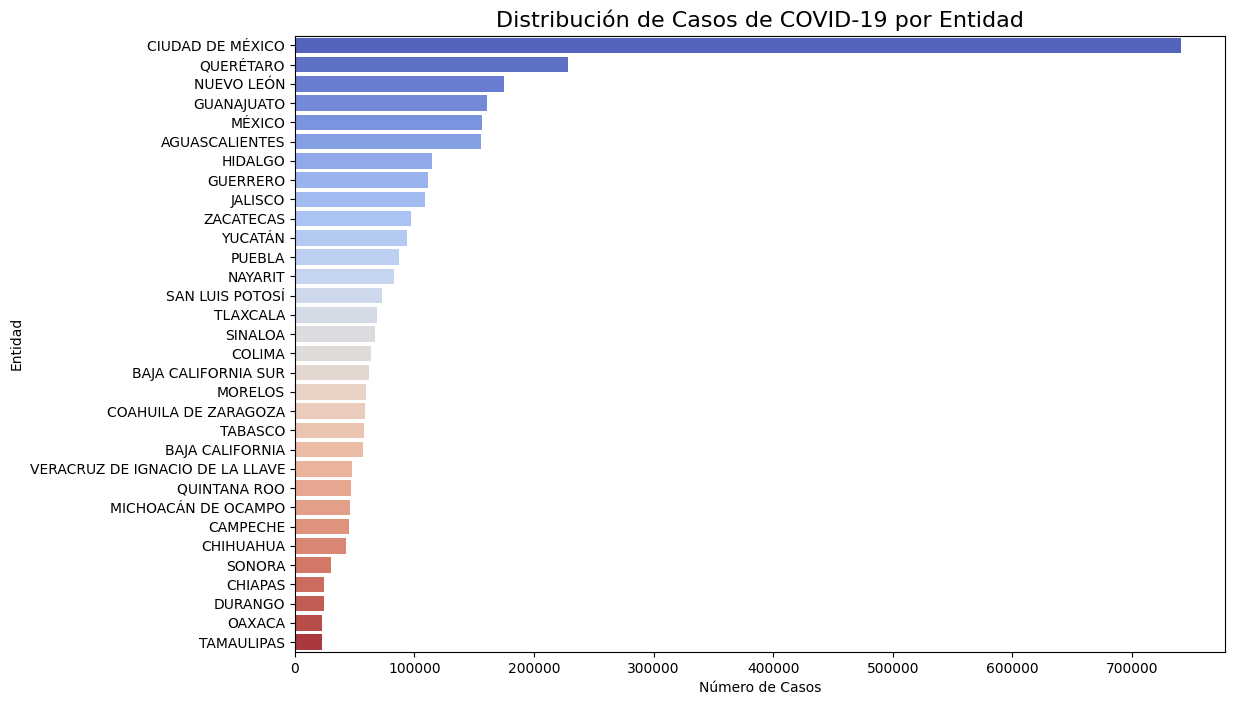

,Entidad,Total Casos
0,CIUDAD DE MÉXICO,740706
1,QUERÉTARO,228033
2,NUEVO LEÓN,174648
3,GUANAJUATO,160808
4,MÉXICO,156669


In [126]:
casos_por_entidad = df_covid19V3['ENTIDAD_RES'].value_counts().reset_index()
casos_por_entidad.columns = ['Entidad', 'Total Casos']

# Visualizamos la distribución de casos por entidad
plt.figure(figsize=(12, 8))
sns.barplot(x='Total Casos', y='Entidad', data=casos_por_entidad, palette='coolwarm')
plt.title('Distribución de Casos de COVID-19 por Entidad', fontsize=16)
plt.xlabel('Número de Casos')
plt.ylabel('Entidad')
plt.savefig('Distribución de casos de Covid-19 por entidad.png', dpi=300)
plt.show()

# Mostrar la tabla de casos por entidad
casos_por_entidad.head()

# Tendencia temporal de ingresos, inicio de síntomas y defunción

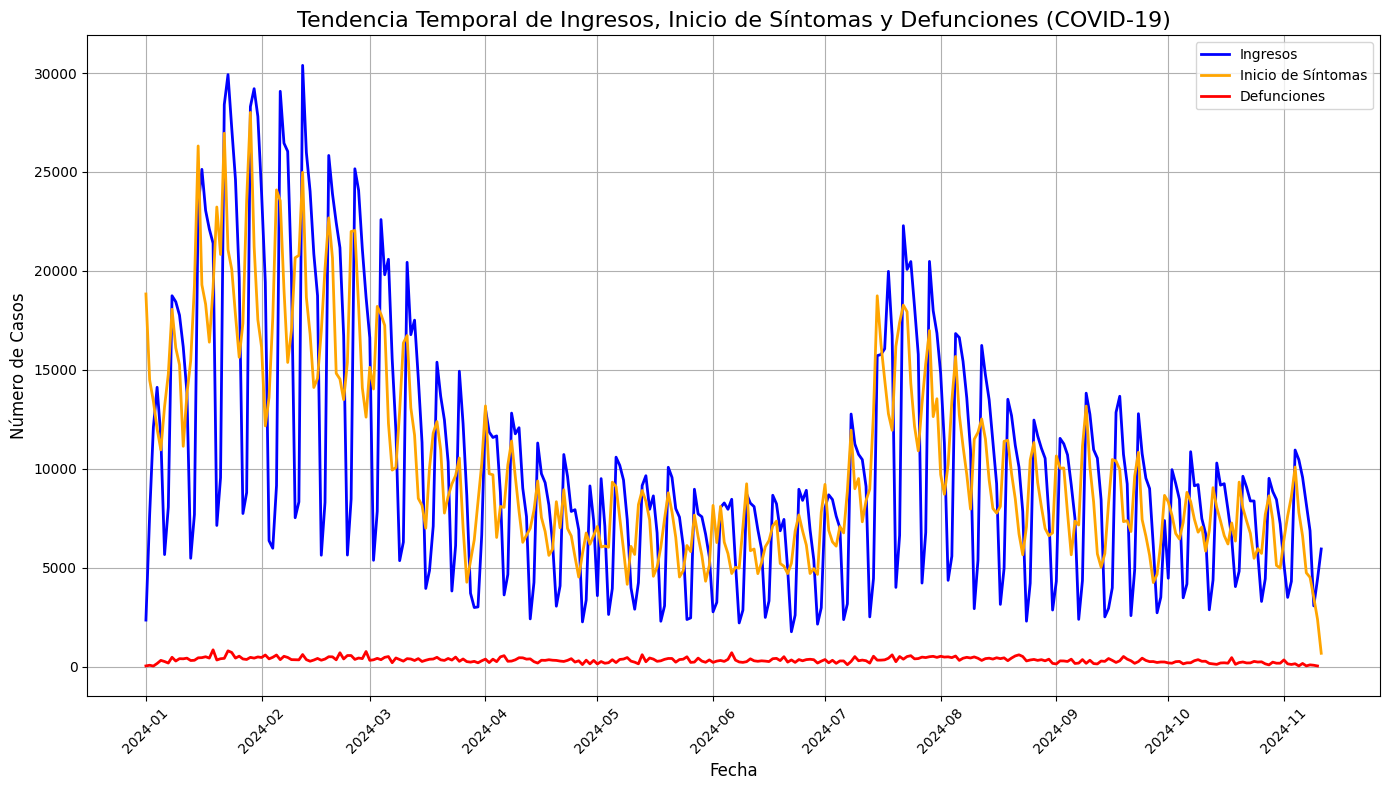

In [127]:
# Agrupamos los datos por fecha y contamos el número de ocurrencias para cada evento (ingresos, síntomas, defunciones)
ingresos_por_dia = df_covid19V3['FECHA_INGRESO'].value_counts().sort_index()
sintomas_por_dia = df_covid19V3['FECHA_SINTOMAS'].value_counts().sort_index()
defunciones_por_dia = df_covid19V3['FECHA_DEF'].value_counts().sort_index()

# Graficamos las tendencias temporales de ingresos, inicio de síntomas y defunciones
plt.figure(figsize=(14, 8))

# Ingresos
plt.plot(ingresos_por_dia.index, ingresos_por_dia.values, label='Ingresos', color='blue', linewidth=2)

# Inicio de síntomas
plt.plot(sintomas_por_dia.index, sintomas_por_dia.values, label='Inicio de Síntomas', color='orange', linewidth=2)

# Defunciones
plt.plot(defunciones_por_dia.index, defunciones_por_dia.values, label='Defunciones', color='red', linewidth=2)

# Ajustes finales del gráfico
plt.title('Tendencia Temporal de Ingresos, Inicio de Síntomas y Defunciones (COVID-19)', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Tendencia temporal de ingresos, inicio de sintomas y defunciones.png', dpi=300)
plt.show()

#  Información sobre el género de los individuos infectados.

Distribución de casos por género:
SEXO
Hombre    1847198
Mujer     1385518
Name: count, dtype: int64


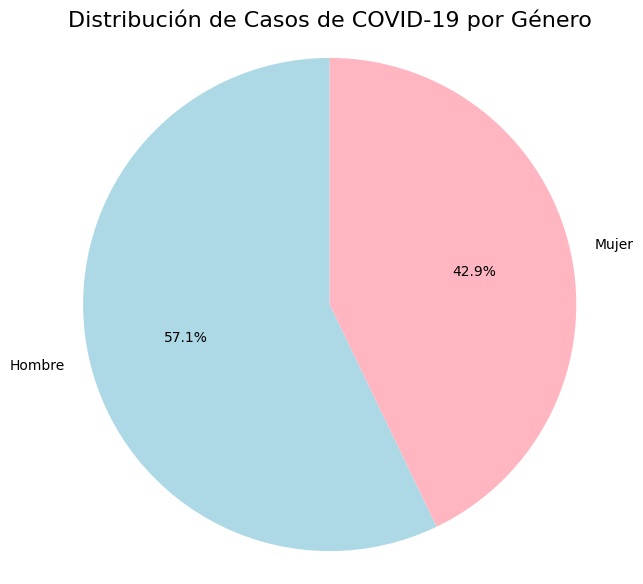

In [128]:
# Contamos el número de casos por género (columna 'SEXO')
# Asegúrate de que 'SEXO' está limpio con etiquetas 'Hombre' y 'Mujer'
casos_por_genero = df_covid19V3['SEXO'].value_counts()

# Imprimimos la distribución de casos por género
print("Distribución de casos por género:")
print(casos_por_genero)

# Visualizamos la distribución de casos por género en un gráfico de pastel
plt.figure(figsize=(7, 7))
plt.pie(casos_por_genero, labels=casos_por_genero.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightpink'])
plt.title('Distribución de Casos de COVID-19 por Género', fontsize=16)
plt.axis('equal')  # Asegura que el gráfico de pastel sea circular
plt.savefig('Distribución de Casos de COVID-19 por género.png', dpi=300)
plt.show()

# Información sobre los individuos que ingresaron a cuidados intensivos.

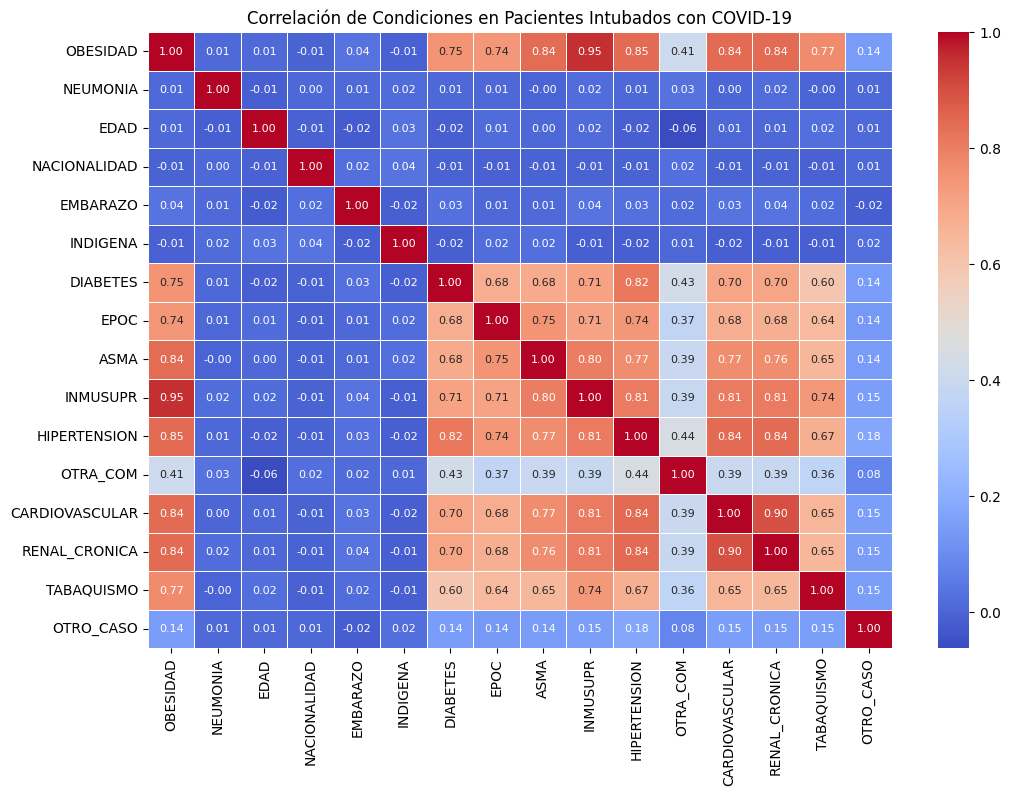

In [129]:
# Filtrar pacientes intubados
df_covid19V2_intubado = df_covid19V3[df_covid19V3['INTUBADO'] == 1]  # Usamos 1 para "Sí"

# Seleccionar las columnas de interés
df_covid19V2_resultado = df_covid19V2_intubado[['OBESIDAD', 'NEUMONIA', 'EDAD',
                                                'NACIONALIDAD', 'EMBARAZO', 'INDIGENA', 'DIABETES',
                                                'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM',
                                                'CARDIOVASCULAR', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO']]

# Reemplazar valores específicos por NaN
df_covid19V2_resultado = df_covid19V2_resultado.replace(['Se ignora', 'No Aplica', 'No especificado'], np.nan)

# Eliminar filas con valores NaN
df_covid19V2_resultado_clean = df_covid19V2_resultado.dropna()

# Crear el heatmap de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(df_covid19V2_resultado_clean.corr(), annot=True,annot_kws={"size": 8}, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Correlación de Condiciones en Pacientes Intubados con COVID-19')
plt.savefig('Correlacion_Condiciones_Pacientes_Intubados_COVID19.png', dpi=300)
plt.show()
